In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll

In [2]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [3]:
def get_swiss_roll(n_samples=5000):
    # Generate 3D swiss roll, but we only extract 2 dimensions to make it a 2D spiral
    data, _ = make_swiss_roll(n_samples=n_samples, noise=0.2)
    data = data[:, [0, 2]]
    # Standardize data to have zero mean and reasonable variance
    data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)
    return torch.tensor(data, dtype=torch.float32)

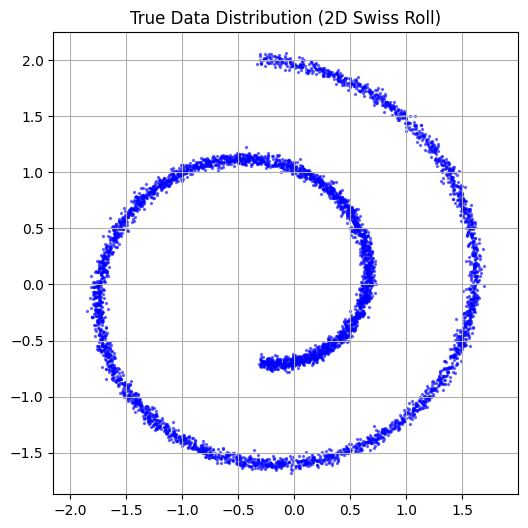

In [4]:
dataset = get_swiss_roll(5000)
plt.figure(figsize=(6, 6))
plt.scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color='blue')
plt.title("True Data Distribution (2D Swiss Roll)")
plt.axis('equal')
plt.grid(True)
plt.show()

In [5]:
class ScoreNetwork(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()
        # Input is 3-dimensional: 2D coordinate + 1D scalar sigma
        self.net = nn.Sequential(
            nn.Linear(3, hidden_dim),
            nn.Softplus(), # Softplus ensures smooth second derivatives for score matching
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Softplus(),
            nn.Linear(hidden_dim, 2) # Output is a 2D vector (the score)
        )
        
    def forward(self, x, sigma):
        # x shape: [batch_size, 2]
        # sigma shape: [batch_size, 1]
        inputs = torch.cat([x, sigma], dim=-1)
        return self.net(inputs)

In [169]:
L = 10                 # Number of noise scales
sigma_1 = 2.0           # High noise (blankets the empty canvas space)
sigma_L = 0.01          # Low noise (resolves fine structure)

In [170]:
# Calculate geometric progression base gamma
gamma = (sigma_L / sigma_1) ** (1.0 / (L - 1))
sigmas = torch.tensor([sigma_1 * (gamma ** i) for i in range(L)], dtype=torch.float32)

In [171]:
print("Noise Schedule (sigmas):")
for idx, s in enumerate(sigmas):
    print(f"Level {idx+1}: {s.item():.4f}")

Noise Schedule (sigmas):
Level 1: 2.0000
Level 2: 1.1101
Level 3: 0.6162
Level 4: 0.3420
Level 5: 0.1898
Level 6: 0.1054
Level 7: 0.0585
Level 8: 0.0325
Level 9: 0.0180
Level 10: 0.0100


In [172]:
network = ScoreNetwork(hidden_dim=128)
optimizer = optim.Adam(network.parameters(), lr=0.001)
epochs = 30000
batch_size = 128

In [173]:
for epoch in range(epochs):
    # 1. Sample a clean batch of data
    idx = torch.randint(0, len(dataset), (batch_size,))
    x_clean = dataset[idx]
    
    # 2. Randomly sample an index for the noise schedule per batch item
    noise_idx = torch.randint(0, L, (batch_size,))
    sigma = sigmas[noise_idx].unsqueeze(-1) # Shape: [batch_size, 1]
    
    # 3. Sample pure Gaussian noise
    z = torch.randn_like(x_clean)
    
    # 4. Create the perturbed noisy data
    x_noisy = x_clean + sigma * z
    
    # 5. Compute true analytical score target: -z / sigma
    target_score = -z / sigma
    
    # 6. Forward pass through network
    predicted_score = network(x_noisy, sigma)
    
    # 7. Weighted MSE Loss (scaled by sigma^2 to prevent high noise from drowning out low noise)
    loss = 0.5 * torch.mean(sigma**2 * torch.sum((predicted_score - target_score) ** 2, dim=-1))
    
    # Optimization step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 400 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {loss.item():.4f}")

Epoch [400/30000] | Loss: 857.7060
Epoch [800/30000] | Loss: 911.7180
Epoch [1200/30000] | Loss: 649.6479
Epoch [1600/30000] | Loss: 684.2015
Epoch [2000/30000] | Loss: 779.8907
Epoch [2400/30000] | Loss: 805.9482
Epoch [2800/30000] | Loss: 506.7528
Epoch [3200/30000] | Loss: 876.7894
Epoch [3600/30000] | Loss: 1400.8271
Epoch [4000/30000] | Loss: 765.8026
Epoch [4400/30000] | Loss: 857.4357
Epoch [4800/30000] | Loss: 997.4894
Epoch [5200/30000] | Loss: 583.2646
Epoch [5600/30000] | Loss: 1105.4462
Epoch [6000/30000] | Loss: 615.8468
Epoch [6400/30000] | Loss: 1253.6704
Epoch [6800/30000] | Loss: 611.2008
Epoch [7200/30000] | Loss: 501.0429
Epoch [7600/30000] | Loss: 727.9296
Epoch [8000/30000] | Loss: 831.6389
Epoch [8400/30000] | Loss: 799.6855
Epoch [8800/30000] | Loss: 716.5644
Epoch [9200/30000] | Loss: 535.7429
Epoch [9600/30000] | Loss: 1129.2133
Epoch [10000/30000] | Loss: 987.8643
Epoch [10400/30000] | Loss: 826.4099
Epoch [10800/30000] | Loss: 832.5065
Epoch [11200/30000] | L

In [181]:
def sample_annealed_langevin(network, sigmas, n_samples=1000, T=20, eps=0.00002):
    network.eval()
    with torch.no_grad():
        # Start from a broad Gaussian distribution matching our highest noise scale
        x = torch.randn(n_samples, 2) * sigmas[0]
        
        # Outer Loop: Walk down through the noise levels from highest to lowest
        for i, sigma in enumerate(sigmas):
            # Compute step size dynamically scaled for this level
            alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
            sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
            # Inner Loop: Run Langevin Dynamics for T steps at this noise level
            for t in range(T):
                # 1. Get the score vector field from our network
                score = network(x, sigma_tensor)
                
                # 2. Add fresh noise for the random shake
                z = torch.randn_like(x)
                
                # 3. Update equation
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
                
    return x.numpy()

In [182]:
generated_samples = sample_annealed_langevin(network, sigmas, n_samples=2000, T=50)

In [183]:
samples_bad  = sample_annealed_langevin(network, sigmas, n_samples=1000, T=2)
samples_good = sample_annealed_langevin(network, sigmas, n_samples=1000, T=50)
samples_best = sample_annealed_langevin(network, sigmas, n_samples=1000, T=200)

In [177]:
def plot_samples(dataset, generated_samples):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot True Data
    axes[0].scatter(dataset[:, 0], dataset[:, 1], s=2, alpha=0.5, color='blue')
    axes[0].set_title("True Training Data")
    axes[0].set_xlim(-2.5, 2.5)
    axes[0].set_ylim(-2.5, 2.5)
    axes[0].grid(True)

    # Plot Generated Data
    axes[1].scatter(generated_samples[:, 0], generated_samples[:, 1], s=2, alpha=0.5, color='red')
    axes[1].set_title("Generated Samples (Annealed Langevin)")
    axes[1].set_xlim(-2.5, 2.5)
    axes[1].set_ylim(-2.5, 2.5)
    axes[1].grid(True)

    plt.show()
    

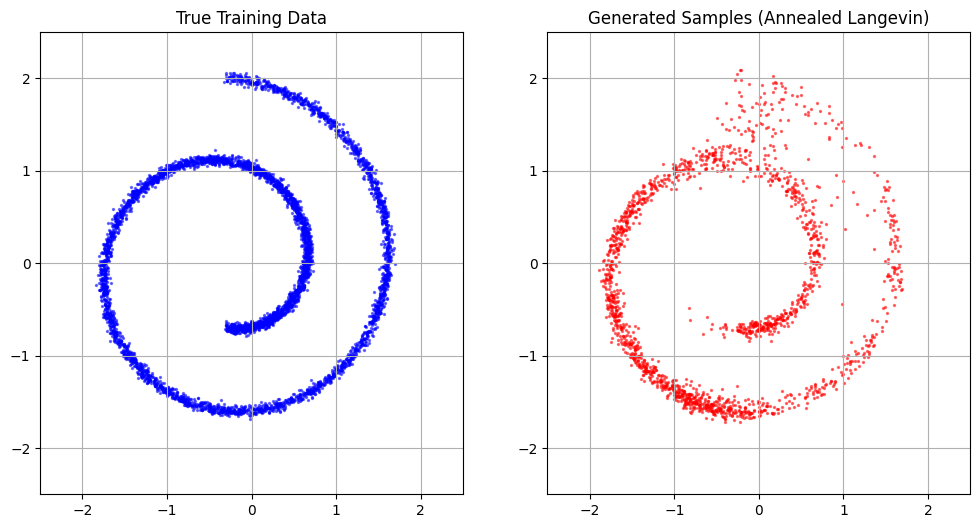

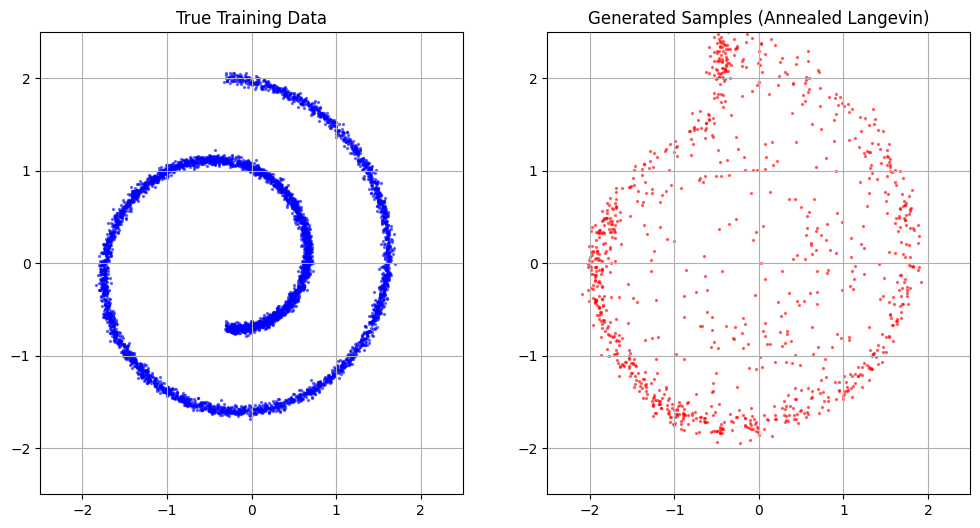

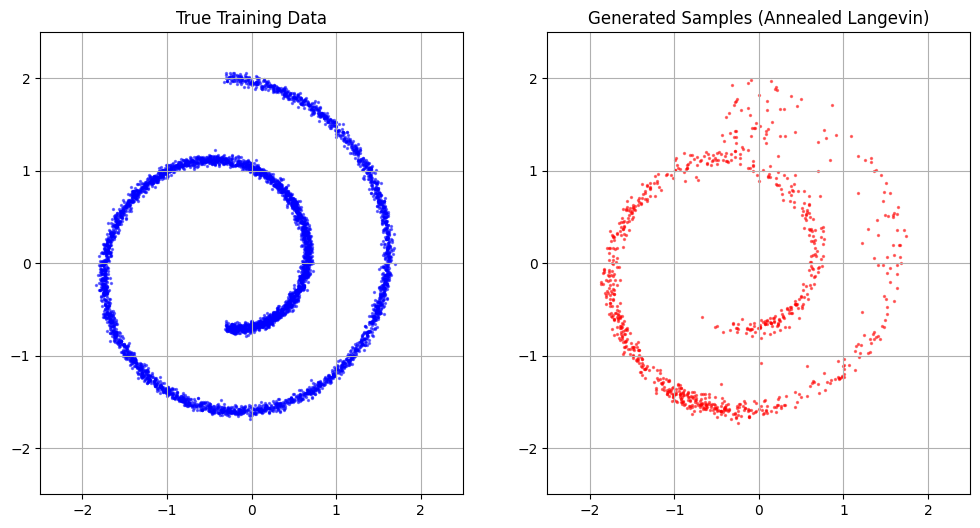

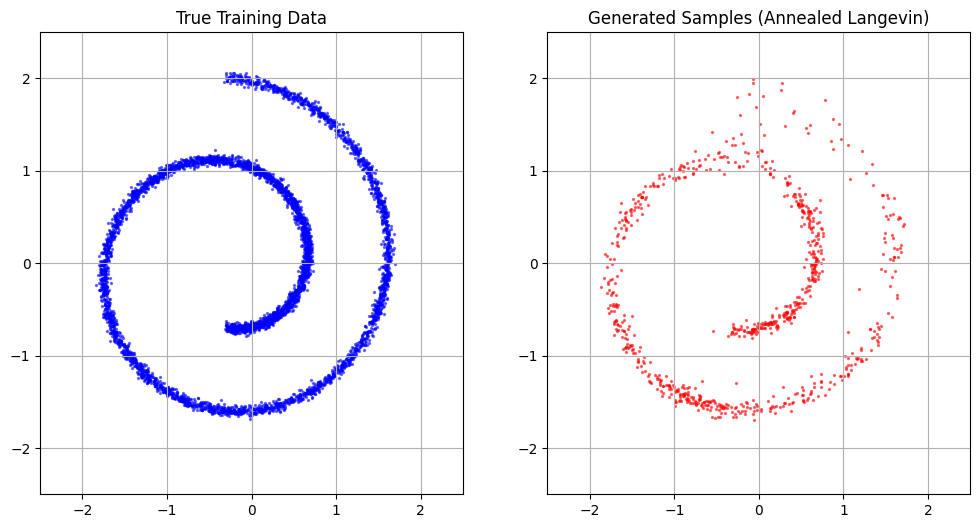

In [185]:
plot_samples(dataset, generated_samples)
plot_samples(dataset, samples_bad)
plot_samples(dataset, samples_good)
plot_samples(dataset, samples_best)

### score field plot

In [213]:
def plot_score_field_grid(network, sigmas, dataset, level_idx=4, grid_res=25):
    """
    Plots the score vector field at a specific noise level index.
    - level_idx: choose which index of the sigmas array to visualize (e.g., 0 to L-1)
    - grid_res: controls how dense the grid of arrows is (20 to 30 is ideal)
    """
    network.eval()
    sigma_val = sigmas[level_idx].item()
    
    # 1. Create a uniform 2D grid covering your data range
    x_range = np.linspace(-2.5, 2.5, grid_res)
    y_range = np.linspace(-2.5, 2.5, grid_res)
    X, Y = np.meshgrid(x_range, y_range)
    
    # Flatten the grid coordinates to feed into PyTorch
    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
    # 2. Create the scalar sigma tensor matching the batch size of the grid
    sigma_tensor = torch.full((grid_tensor.shape[0], 1), sigma_val)
    
    # 3. Predict the score arrows
    with torch.no_grad():
        # Shape: [grid_res * grid_res, 2]
        predicted_scores = network(grid_tensor, sigma_tensor).numpy()
        
    # Reshape vectors back into a 2D grid structure for plotting
    U = predicted_scores[:, 0].reshape(X.shape)
    V = predicted_scores[:, 1].reshape(Y.shape)
    
    
    # 4. Compute magnitudes to visually color-code strong vs weak forces
    magnitudes = np.sqrt(U**2 + V**2)
    
    # 5. Plotting
    plt.figure(figsize=(6, 6))
    
    # Underlay a subset of the true data points for reference
    plt.scatter(dataset[:1000, 0], dataset[:1000, 1], s=4, color='blue', alpha=0.3, label='True Manifold')
    
    # Draw the vector arrows
    # angles='xy', scale_units='xy' ensure arrows scale accurately with the axis units
    quiver = plt.quiver(X, Y, U/magnitudes, V/magnitudes, magnitudes, cmap='inferno', 
                        angles='xy', scale_units='xy', scale=10, alpha=0.8)
    
    plt.colorbar(quiver, label='Score Vector Magnitude')
    plt.title(f"Learned Vector Score Field\nNoise Level {level_idx + 1}/{len(sigmas)} ($\\sigma$ = {sigma_val:.4f})")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.xlim(-2.7, 2.7)
    plt.ylim(-2.7, 2.7)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
    plt.show()

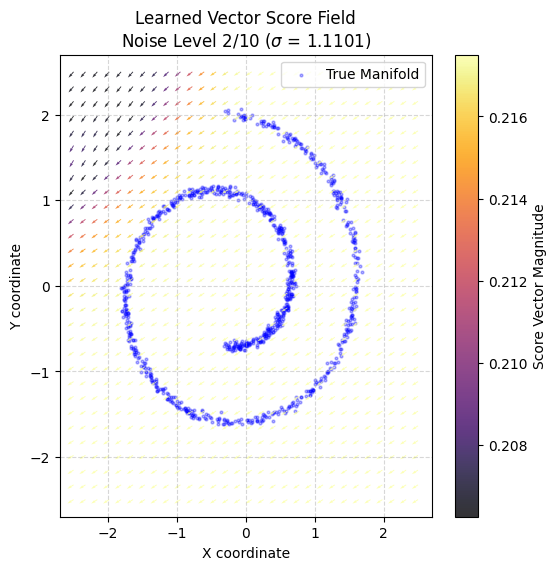

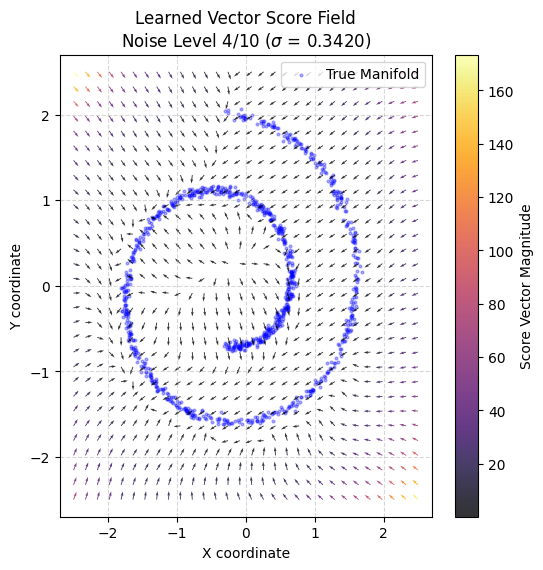

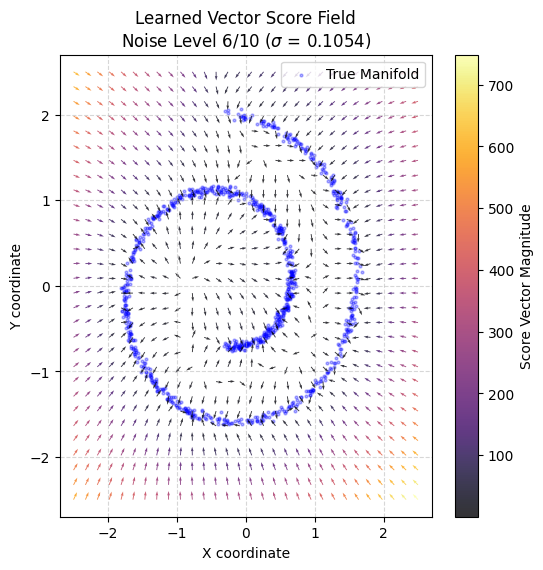

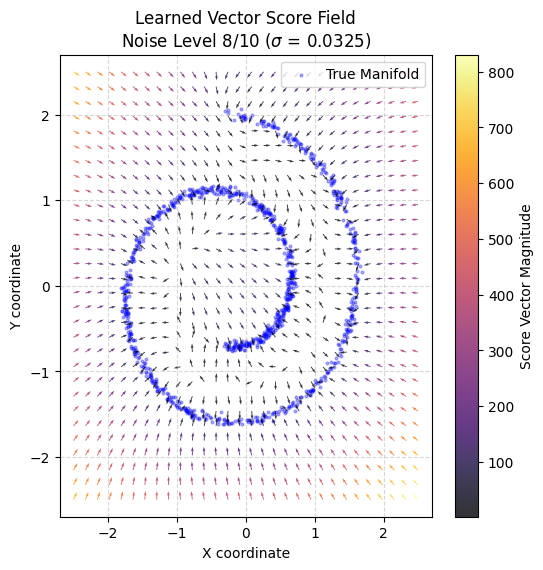

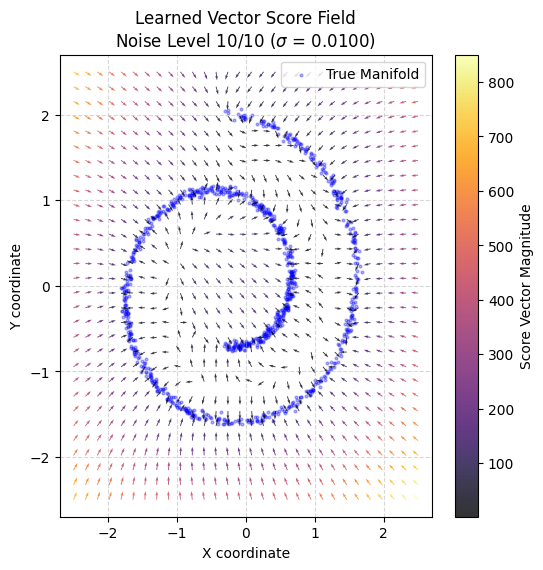

In [216]:
plot_score_field_grid(network, sigmas, dataset, level_idx=1, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=3, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=5, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=7, grid_res=30)
plot_score_field_grid(network, sigmas, dataset, level_idx=9, grid_res=30)

In [ ]:
# def visualize_langevin_evolution(network, sigmas, dataset, n_samples=600, T=100, eps=0.0001):
#     network.eval()
#     L_total = len(sigmas)
    
#     # Select 4 evenly spaced noise levels to visualize the evolution milestones
#     milestone_indices = [0, int(L_total * 0.25), int(L_total * 0.6), L_total - 1]
    
#     # Initialize the particle positions at the maximum noise level
#     x = torch.randn(n_samples, 2) * sigmas[0]
    
#     # Set up a 2x4 grid plot (Top row: Vector Fields | Bottom row: Moving Particles)
#     fig, axes = plt.subplots(2, 4, figsize=(20, 10))
#     col_idx = 0
    
#     # Setup uniform grid arrays for drawing underlying arrows
#     grid_res = 20
#     x_range = np.linspace(-2.5, 2.5, grid_res)
#     y_range = np.linspace(-2.5, 2.5, grid_res)
#     X, Y = np.meshgrid(x_range, y_range)
#     grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
#     grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

#     with torch.no_grad():
#         # Outer Loop: Walk down through the noise levels
#         for idx, sigma in enumerate(sigmas):
#             alpha = eps * (sigma ** 2) / (sigmas[-1] ** 2)
#             sigma_tensor = torch.full((n_samples, 1), sigma.item())
            
#             # If we hit a milestone, generate and plot the background vector field map FIRST
#             if idx in milestone_indices:
#                 grid_sigma = torch.full((grid_tensor.shape[0], 1), sigma.item())
#                 grid_scores = network(grid_tensor, grid_sigma).numpy()
#                 U = grid_scores[:, 0].reshape(X.shape)
#                 V = grid_scores[:, 1].reshape(Y.shape)

#                 eps_stable = 1e-8
#                 norms = np.sqrt(U**2 + V**2) + eps_stable
#                 U_norm = U / norms
#                 V_norm = V / norms

#                 # Plot using the normalized components (U_norm, V_norm)
#                 ax_top = axes[0, col_idx]
#                 ax_top.quiver(X, Y, U_norm, V_norm, color='gray', alpha=0.6, angles='xy', scale_units='xy', scale=12) # Lower scale = slightly longer arrows
                
#                 # Plot the background vector field (Top Row)
#                 # ax_top = axes[0, col_idx]
#                 # ax_top.quiver(X, Y, U, V, color='gray', alpha=0.6, angles='xy', scale_units='xy', scale=20)
#                 ax_top.scatter(dataset[:300, 0], dataset[:300, 1], s=2, color='blue', alpha=0.2)
#                 ax_top.set_title(f"Stage {col_idx+1}: Score Field ($sigma$={sigma.item():.3f})")
#                 ax_top.set_xlim(-2.7, 2.7)
#                 ax_top.set_ylim(-2.7, 2.7)
#                 ax_top.grid(True, alpha=0.3)
            
#             # Inner Loop: Run Langevin Dynamics for T steps at this noise level
#             for t in range(T):
#                 score = network(x, sigma_tensor)
#                 z = torch.randn_like(x)
#                 x = x + 0.5 * alpha * score + torch.sqrt(alpha) * z
                
#             # If we hit a milestone, snapshot where the particles have traveled (Bottom Row)
#             if idx in milestone_indices:
#                 ax_bottom = axes[1, col_idx]
                
#                 # NEW: Safe conversion of tracking tensors to raw plot coordinates
#                 x_numpy = x.detach().cpu().numpy()
                
#                 # Plot the red generated particles
#                 ax_bottom.scatter(x_numpy[:, 0], x_numpy[:, 1], s=3, color='red', alpha=0.6)
#                 ax_bottom.set_title(f"Particle Positions (End of Scale)")
#                 ax_bottom.set_xlim(-2.7, 2.7)
#                 ax_bottom.set_ylim(-2.7, 2.7)
#                 ax_bottom.grid(True, alpha=0.3)
#                 col_idx += 1
                
#     plt.tight_layout()
#     plt.show()

In [ ]:
# visualize_langevin_evolution(network, sigmas, dataset, n_samples=1000, T=80, eps=0.0001)

### comparing generated data with true data using Wasserstein distance

In [ ]:
from scipy.stats import wasserstein_distance

In [ ]:


# 1. Strip gradients, push to CPU, and cast to 64-bit float NumPy arrays
clean_data_np = dataset[:1500].detach().cpu().numpy()
generated_np = torch.tensor(generated_samples).detach().cpu().numpy() # ensure it's a tensor first if needed

# 2. Extract specific 1D coordinate arrays
true_x = clean_data_np[:, 0]
true_y = clean_data_np[:, 1]

gen_x = generated_np[:, 0]
gen_y = generated_np[:, 1]



In [149]:
# 3. Strip out any rows containing NaN or Infinity from the generated coordinates
valid_mask = np.isfinite(gen_x) & np.isfinite(gen_y)
gen_x_clean = gen_x[valid_mask]
gen_y_clean = gen_y[valid_mask]

# 4. Defensive check: Calculate only if we have remaining valid points
if len(gen_x_clean) > 0:
    wd_x = wasserstein_distance(true_x, gen_x_clean)
    wd_y = wasserstein_distance(true_y, gen_y_clean)
    sample_quality_score = wd_x + wd_y
    print(f"Sample Quality Score (Wasserstein): {sample_quality_score:.4f} (Valid points: {len(gen_x_clean)}/{len(gen_x)})")
else:
    print("Warning: All generated samples exploded into NaNs. Reduce your sampling step size 'eps'!")

Sample Quality Score (Wasserstein): 0.1333 (Valid points: 1991/2000)


In [123]:
import numpy as np
from scipy.stats import wasserstein_distance

# Sample two completely independent batches of TRUE clean data
true_batch_1 = dataset[torch.randint(0, len(dataset), (1500,))].numpy()
true_batch_2 = dataset[torch.randint(0, len(dataset), (1500,))].numpy()

# Calculate the distance between true data and itself
base_x = wasserstein_distance(true_batch_1[:, 0], true_batch_2[:, 0])
base_y = wasserstein_distance(true_batch_1[:, 1], true_batch_2[:, 1])
perfect_score = base_x + base_y

print(f"Theoretical 'Perfect' Score Limit: {perfect_score:.4f}")

Theoretical 'Perfect' Score Limit: 0.0457
